In [1]:
# Imports and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')
import os

# Set style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 10

# random seed
np.random.seed(42)

In [3]:
print(f"Current working directory: {os.getcwd()}")

# os.chdir(Path(os.getcwd()).parent)
# print(f"New working directory: {os.getcwd()}")


Current working directory: /home/sjoon/projects/brain_connectivity_classifier


In [4]:
# Load Data
PIOP2_PATH = "data/raw/PIOP2_restingstate.csv"
PIOP1_PATH = "data/raw/PIOP1_gstroop.csv"

# Load datasets
df_rest = pd.read_csv(PIOP2_PATH)
df_task = pd.read_csv(PIOP1_PATH)

print(f"PIOP2 (Rest) shape: {df_rest.shape}")
print(f"PIOP1 (Task) shape: {df_task.shape}")
print(f"\nFirst few columns: {list(df_rest.columns[:5])}")

PIOP2 (Rest) shape: (224, 26797)
PIOP1 (Task) shape: (200, 26797)

First few columns: ['subject', 'LH_VisCent_ExStr_2~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_2', 'LH_VisCent_ExStr_3~LH_VisCent_ExStr_1']


In [5]:
# Extract subject IDs and connection data
subject_col = df_rest.columns[0]
connection_cols = [col for col in df_rest.columns if '~' in str(col)]

print(f"Subject ID column: {subject_col}")
print(f"Number of connection columns: {len(connection_cols)}")
print(f"Sample connection columns: {connection_cols[:3]}")

# Extract connectivity matrices
X_rest = df_rest[connection_cols].values
X_task = df_task[connection_cols].values

print(f"\nX_rest shape: {X_rest.shape}")
print(f"X_task shape: {X_task.shape}")

Subject ID column: subject
Number of connection columns: 26796
Sample connection columns: ['LH_VisCent_ExStr_2~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_2']

X_rest shape: (224, 26796)
X_task shape: (200, 26796)


In [6]:
# Per-Connection Difference Analysis
print("SECTION 3: CONNECTION-LEVEL ANALYSIS")

# Calculate mean connectivity for each connection
rest_connection_means = X_rest.mean(axis=0)
task_connection_means = X_task.mean(axis=0)

# Calculate difference
connection_diff = task_connection_means - rest_connection_means

# Calculate per-connection t-tests
connection_pvals = np.zeros(len(connection_cols))
connection_tvals = np.zeros(len(connection_cols))

print("\n3.1 Computing per-connection t-tests...")
for i in range(len(connection_cols)):
    t_val, p_val = stats.ttest_ind(X_rest[:, i], X_task[:, i])
    connection_tvals[i] = t_val
    connection_pvals[i] = p_val

# FDR correction (Benjamini-Hochberg)
from scipy.stats import false_discovery_control
significant_fdr = false_discovery_control(connection_pvals, method='bh')

n_significant = significant_fdr.sum()
print(f"\n3.2 Statistical Significance:")
print(f"  Total connections: {len(connection_cols)}")
print(f"  Significant (FDR < 0.05): {n_significant} ({100*n_significant/len(connection_cols):.2f}%)")

# Summary statistics
print(f"\n3.3 Connection Difference Statistics:")
print(f"  Mean difference: {connection_diff.mean():.4f}")
print(f"  Std difference: {connection_diff.std():.4f}")
print(f"  Min difference: {connection_diff.min():.4f}")
print(f"  Max difference: {connection_diff.max():.4f}")
print(f"  Connections with |Δ| > 0.1: {(np.abs(connection_diff) > 0.1).sum()}")

# Create DataFrame for analysis
connection_analysis = pd.DataFrame({
    'connection': connection_cols,
    'rest_mean': rest_connection_means,
    'task_mean': task_connection_means,
    'difference': connection_diff,
    'abs_difference': np.abs(connection_diff),
    't_statistic': connection_tvals,
    'p_value': connection_pvals,
    'significant_fdr': significant_fdr
})

# Sort by absolute difference
connection_analysis = connection_analysis.sort_values('abs_difference', ascending=False).reset_index(drop=True)

# Display top changed connections
print(f"\n3.4 Top 10 Changed Connections:")
print(connection_analysis[['connection', 'rest_mean', 'task_mean', 'difference', 'p_value']].head(10).to_string())

SECTION 3: CONNECTION-LEVEL ANALYSIS

3.1 Computing per-connection t-tests...

3.2 Statistical Significance:
  Total connections: 26796
  Significant (FDR < 0.05): 9252.813557067962 (34.53%)

3.3 Connection Difference Statistics:
  Mean difference: -0.0008
  Std difference: 0.0497
  Min difference: -0.5164
  Max difference: 0.2376
  Connections with |Δ| > 0.1: 1386

3.4 Top 10 Changed Connections:
                                    connection  rest_mean  task_mean  difference       p_value
0                    RH_SomMotA_4~LH_SomMotA_3   0.592718   0.076292   -0.516426  6.241642e-78
1                    RH_SomMotA_6~LH_SomMotA_3   0.462165   0.059750   -0.402415  6.017485e-51
2                    RH_SomMotA_4~LH_SomMotA_2   0.441576   0.113189   -0.328387  1.138043e-41
3                    RH_SomMotA_1~LH_SomMotA_3   0.332238   0.039495   -0.292742  2.841239e-32
4                    RH_SomMotA_4~LH_SomMotA_4   0.394927   0.105769   -0.289158  3.657703e-34
5                    RH_SomMo

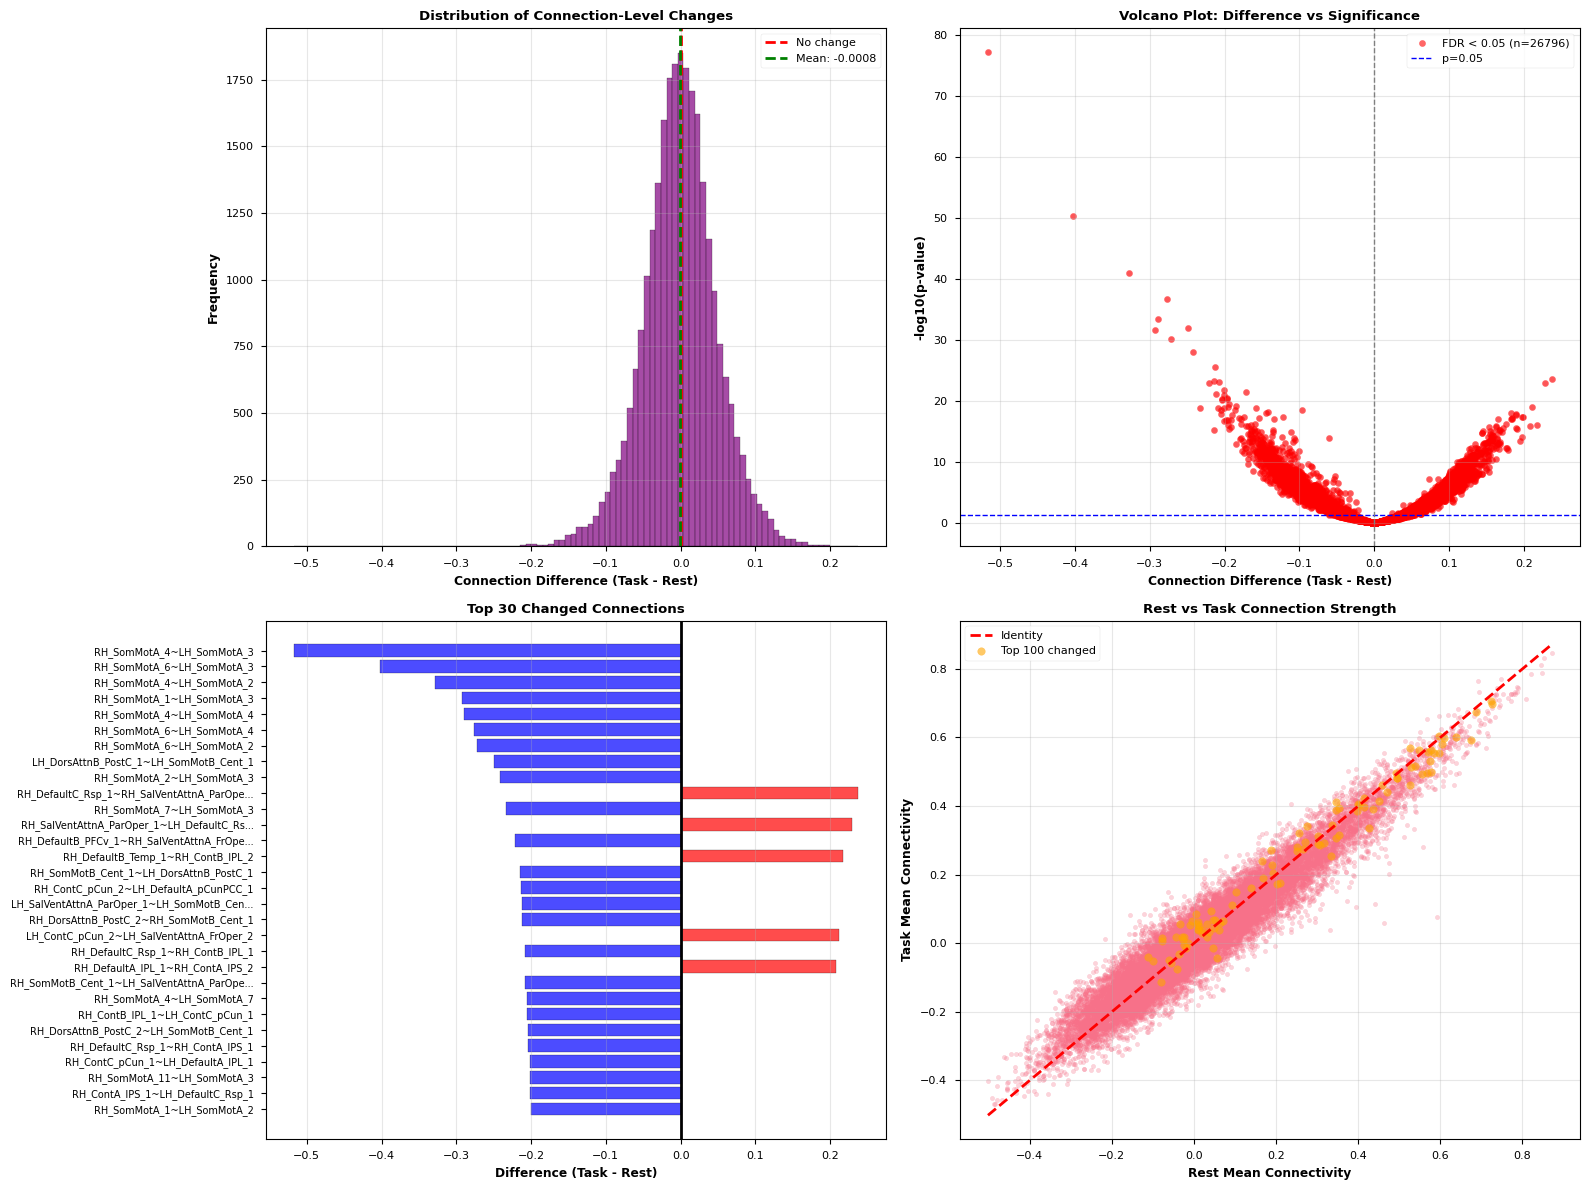

In [7]:
# Visualize Connection-Level Differences
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram of differences
axes[0, 0].hist(connection_diff, bins=100, alpha=0.7, color='purple', edgecolor='black')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
axes[0, 0].axvline(connection_diff.mean(), color='green', linestyle='--', linewidth=2, 
                   label=f'Mean: {connection_diff.mean():.4f}')
axes[0, 0].set_xlabel('Connection Difference (Task - Rest)', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Distribution of Connection-Level Changes', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Volcano plot
neg_log_p = -np.log10(connection_pvals + 1e-300)  # Add small value to avoid log(0)
axes[0, 1].scatter(connection_diff, neg_log_p, alpha=0.3, s=10)

# Highlight significant connections - use directly as boolean mask
sig_mask = significant_fdr.astype(bool)  # Ensure it's boolean type
axes[0, 1].scatter(connection_diff[sig_mask], neg_log_p[sig_mask], 
                   color='red', alpha=0.6, s=20, label=f'FDR < 0.05 (n={sig_mask.sum()})')

axes[0, 1].axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=1, label='p=0.05')
axes[0, 1].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Connection Difference (Task - Rest)', fontweight='bold')
axes[0, 1].set_ylabel('-log10(p-value)', fontweight='bold')
axes[0, 1].set_title('Volcano Plot: Difference vs Significance', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Top 30 changed connections
top_30 = connection_analysis.head(30)
y_pos = np.arange(len(top_30))
colors = ['red' if d > 0 else 'blue' for d in top_30['difference']]

axes[1, 0].barh(y_pos, top_30['difference'], color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels([c[:40] + '...' if len(c) > 40 else c for c in top_30['connection']], 
                           fontsize=7)
axes[1, 0].axvline(0, color='black', linewidth=2)
axes[1, 0].set_xlabel('Difference (Task - Rest)', fontweight='bold')
axes[1, 0].set_title('Top 30 Changed Connections', fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Scatter: Rest vs Task mean
axes[1, 1].scatter(rest_connection_means, task_connection_means, alpha=0.3, s=10)
# Add identity line
min_val = min(rest_connection_means.min(), task_connection_means.min())
max_val = max(rest_connection_means.max(), task_connection_means.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Identity')

# Highlight top changed
top_changed_idx = connection_analysis.head(100).index
axes[1, 1].scatter(rest_connection_means[top_changed_idx], 
                   task_connection_means[top_changed_idx],
                   color='orange', s=30, alpha=0.6, label='Top 100 changed')

axes[1, 1].set_xlabel('Rest Mean Connectivity', fontweight='bold')
axes[1, 1].set_ylabel('Task Mean Connectivity', fontweight='bold')
axes[1, 1].set_title('Rest vs Task Connection Strength', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Extract Network Information from Region Names
print("SECTION 4: NETWORK-LEVEL PATTERNS")

def parse_network_from_region(region_name):
    """Extract network from region name."""
    name = region_name.lower()
    
    # Cortical networks
    if 'vis' in name:
        if 'cent' in name:
            return 'Visual_Central'
        elif 'peri' in name:
            return 'Visual_Peripheral'
        else:
            return 'Visual'
    elif 'sommot' in name or 'senmot' in name:
        if 'a' in name.split('_')[-1]:
            return 'Somatomotor_A'
        elif 'b' in name.split('_')[-1]:
            return 'Somatomotor_B'
        else:
            return 'Somatomotor'
    elif 'dorsattn' in name:
        if 'a' in name.split('_')[-1]:
            return 'DorsalAttn_A'
        elif 'b' in name.split('_')[-1]:
            return 'DorsalAttn_B'
        else:
            return 'DorsalAttention'
    elif 'salventattn' in name:
        if 'a' in name.split('_')[-1]:
            return 'VentralAttn_A'
        elif 'b' in name.split('_')[-1]:
            return 'VentralAttn_B'
        else:
            return 'VentralAttention'
    elif 'limbic' in name:
        return 'Limbic'
    elif 'cont' in name:
        return 'FrontoParietal'
    elif 'default' in name:
        return 'DefaultMode'
    elif 'temppar' in name:
        return 'TemporalParietal'
    # Subcortical
    elif 'hip' in name:
        return 'Hippocampus'
    elif 'amy' in name:
        return 'Amygdala'
    elif 'tha' in name:
        return 'Thalamus'
    elif 'nac' in name:
        return 'Accumbens'
    elif 'put' in name:
        return 'Putamen'
    elif 'cau' in name:
        return 'Caudate'
    elif 'gp' in name or 'pallidum' in name:
        return 'Pallidum'
    else:
        return 'Other'

# Parse networks for each connection
print("\n4.1 Parsing network information from connection names...")
network_pairs = []
for conn in connection_cols:
    parts = conn.split('~')
    if len(parts) == 2:
        net1 = parse_network_from_region(parts[0])
        net2 = parse_network_from_region(parts[1])
        
        # Create ordered pair (alphabetically)
        pair = tuple(sorted([net1, net2]))
        network_pairs.append(pair)
    else:
        network_pairs.append(('Unknown', 'Unknown'))

# Add to connection analysis
connection_analysis['network_pair'] = network_pairs
connection_analysis['network_1'] = [p[0] for p in network_pairs]
connection_analysis['network_2'] = [p[1] for p in network_pairs]

# Categorize as within or between network
connection_analysis['connection_type'] = [
    'Within-Network' if n1 == n2 else 'Between-Network' 
    for n1, n2 in network_pairs
]

print(f"✓ Parsed {len(connection_cols)} connections into network pairs")

# Count network pairs
network_pair_counts = pd.Series(network_pairs).value_counts()
print(f"\n4.2 Top 10 Network Pairs by Connection Count:")
print(network_pair_counts.head(10))

SECTION 4: NETWORK-LEVEL PATTERNS

4.1 Parsing network information from connection names...
✓ Parsed 26796 connections into network pairs

4.2 Top 10 Network Pairs by Connection Count:
(DefaultMode, FrontoParietal)         1369
(FrontoParietal, Somatomotor)         1258
(DefaultMode, Somatomotor)            1258
(DefaultMode, VentralAttention)        962
(FrontoParietal, VentralAttention)     962
(Somatomotor, VentralAttention)        884
(DefaultMode, DorsalAttention)         814
(DorsalAttention, FrontoParietal)      814
(DorsalAttention, Somatomotor)         748
(FrontoParietal, FrontoParietal)       666
Name: count, dtype: int64


In [9]:
# Within vs Between Network Changes
print("\n4.3 Within-Network vs Between-Network Analysis:")

within_net = connection_analysis[connection_analysis['connection_type'] == 'Within-Network']
between_net = connection_analysis[connection_analysis['connection_type'] == 'Between-Network']

print(f"  Within-network connections: {len(within_net)}")
print(f"  Between-network connections: {len(between_net)}")

# Compare changes
within_diff = within_net['abs_difference'].values
between_diff = between_net['abs_difference'].values

print(f"\n  Within-network mean |Δ|: {within_diff.mean():.4f}")
print(f"  Between-network mean |Δ|: {between_diff.mean():.4f}")

# Statistical test
t_stat, p_val = stats.ttest_ind(within_diff, between_diff)
print(f"\n  T-test comparing within vs between:")
print(f"    t-statistic: {t_stat:.4f}")
print(f"    p-value: {p_val:.4e}")
if p_val < 0.05:
    print(f"    ✓ Significant difference (p < 0.05)")


4.3 Within-Network vs Between-Network Analysis:
  Within-network connections: 2751
  Between-network connections: 24045

  Within-network mean |Δ|: 0.0506
  Between-network mean |Δ|: 0.0365

  T-test comparing within vs between:
    t-statistic: 22.0953
    p-value: 3.1819e-107
    ✓ Significant difference (p < 0.05)


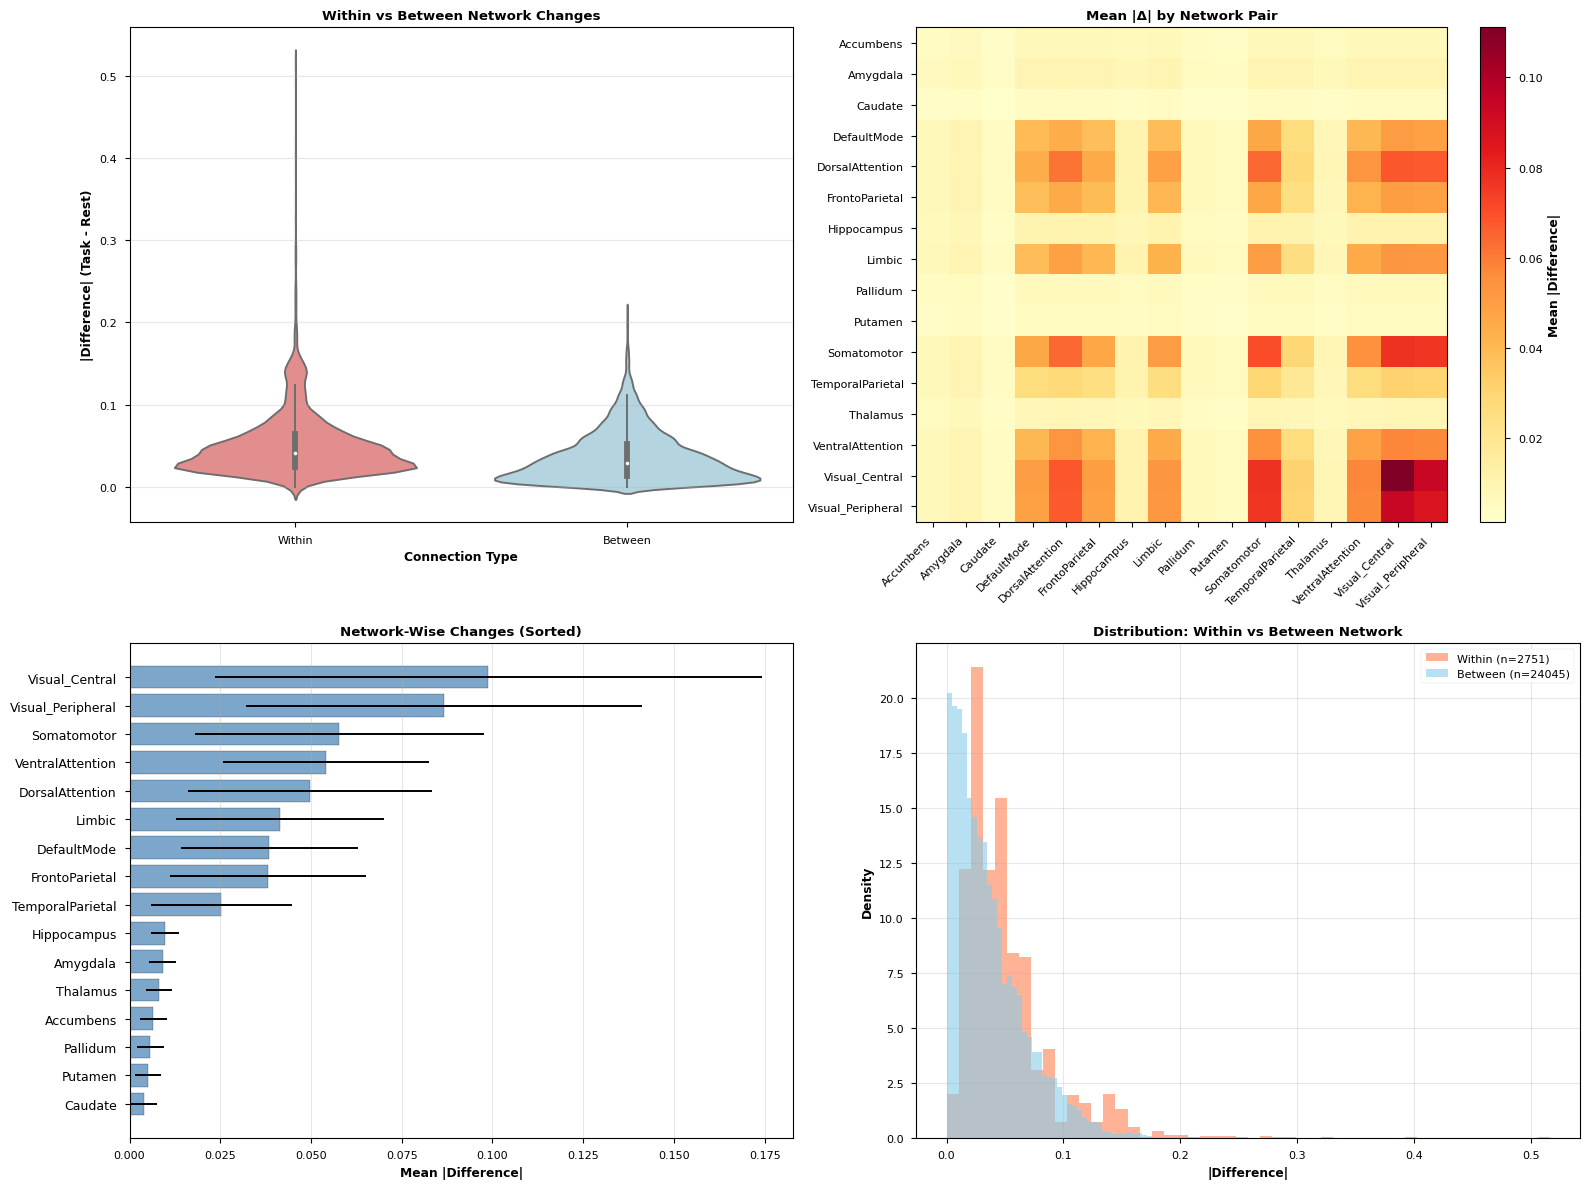

In [10]:
# Visualize Network-Level Patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Within vs Between network changes
violin_data = pd.DataFrame({
    'abs_difference': np.concatenate([within_diff, between_diff]),
    'type': ['Within']*len(within_diff) + ['Between']*len(between_diff)
})

sns.violinplot(data=violin_data, x='type', y='abs_difference', ax=axes[0, 0],
               palette={'Within': 'lightcoral', 'Between': 'lightblue'})
axes[0, 0].set_ylabel('|Difference| (Task - Rest)', fontweight='bold')
axes[0, 0].set_xlabel('Connection Type', fontweight='bold')
axes[0, 0].set_title('Within vs Between Network Changes', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Network-pair heatmap of mean changes
# Create matrix of network pair changes
unique_networks = sorted(set([n for pair in network_pairs for n in pair if n != 'Unknown' and n != 'Other']))
n_nets = len(unique_networks)
network_change_matrix = np.zeros((n_nets, n_nets))
network_count_matrix = np.zeros((n_nets, n_nets))

for i, net1 in enumerate(unique_networks):
    for j, net2 in enumerate(unique_networks):
        mask = ((connection_analysis['network_1'] == net1) & (connection_analysis['network_2'] == net2)) | \
               ((connection_analysis['network_1'] == net2) & (connection_analysis['network_2'] == net1))
        if mask.any():
            network_change_matrix[i, j] = connection_analysis[mask]['abs_difference'].mean()
            network_count_matrix[i, j] = mask.sum()

# Plot heatmap
im = axes[0, 1].imshow(network_change_matrix, cmap='YlOrRd', aspect='auto')
axes[0, 1].set_xticks(np.arange(n_nets))
axes[0, 1].set_yticks(np.arange(n_nets))
axes[0, 1].set_xticklabels(unique_networks, rotation=45, ha='right', fontsize=8)
axes[0, 1].set_yticklabels(unique_networks, fontsize=8)
axes[0, 1].set_title('Mean |Δ| by Network Pair', fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=axes[0, 1])
cbar.set_label('Mean |Difference|', fontweight='bold')

# Annotate with values (only if not too many networks)
if n_nets <= 12:
    for i in range(n_nets):
        for j in range(n_nets):
            if network_count_matrix[i, j] > 0:
                text = axes[0, 1].text(j, i, f'{network_change_matrix[i, j]:.3f}',
                                      ha="center", va="center", color="black", fontsize=6)

# Network-wise comparison
network_changes = connection_analysis.groupby('network_1').agg({
    'abs_difference': ['mean', 'std', 'count']
}).reset_index()
network_changes.columns = ['network', 'mean_change', 'std_change', 'n_connections']
network_changes = network_changes[network_changes['network'] != 'Unknown']
network_changes = network_changes[network_changes['network'] != 'Other']
network_changes = network_changes.sort_values('mean_change', ascending=False)

# Bar plot
y_pos = np.arange(len(network_changes))
axes[1, 0].barh(y_pos, network_changes['mean_change'], 
                xerr=network_changes['std_change'],
                alpha=0.7, color='steelblue', edgecolor='black', capsize=3)
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels(network_changes['network'], fontsize=9)
axes[1, 0].set_xlabel('Mean |Difference|', fontweight='bold')
axes[1, 0].set_title('Network-Wise Changes (Sorted)', fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Distribution comparison
axes[1, 1].hist(within_diff, bins=50, alpha=0.6, color='coral', 
               label=f'Within (n={len(within_diff)})', density=True)
axes[1, 1].hist(between_diff, bins=50, alpha=0.6, color='skyblue', 
               label=f'Between (n={len(between_diff)})', density=True)
axes[1, 1].set_xlabel('|Difference|', fontweight='bold')
axes[1, 1].set_ylabel('Density', fontweight='bold')
axes[1, 1].set_title('Distribution: Within vs Between Network', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Save network-level summary
# network_changes.to_csv('reports/tables/eda/network_level_changes.csv', index=False)
